# Notebook 4: Empirical Heat Kernel on $S^2$

From the previous notebooks and `src/sphere.py`, Brownian motion was simulated on a unit sphere $S^2$, where

$$
S^2 = {x \in \mathbb{R}^3 : |x| = 1}
$$

If all particles start at a point on the sphere (such as $x_0 = (0, 0, 1)$), then as time increases, we expect the particles to spread over the sphere.

The heat kernel is expressed as $p_t(x, y)$ and represents the probability density of finding a particle at $y$ at time $t$, given that it started at the point $x$. This theoretical distribution satisfies

$$
\int_{S^2} p_t(x_0, y),dV(y) = 1
$$

This normalization should be satisfied when running a simulation.

Since the simulation is being run on a sphere, the spherical coordinates are $\theta$ and $\phi$, where

$$
0 \leq \theta \leq \pi
$$

and

$$
0 \leq \phi < 2\pi
$$

The starting point chosen for this simulation is $(0, 0, 1)$, the north pole of the sphere, so the theoretical heat kernel depends only on $\theta$.

On a sphere, the Riemannian volume element is expressed as

$$
dV = \sin\theta,d\theta,d\phi
$$

This means that the kernel density estimation (KDE) needs to be normalized using the spherical area element instead of treating $(\theta, \phi)$ as Cartesian coordinates. The reasoning for this will be expanded upon in a future Markdown cell.

In this notebook, we will check that the empirical distribution is approximately equal to the theoretical heat kernel at different times.



In [ ]:
# Imports
import numpy as np
from wanderwalk import Sphere
from wanderwalk.heat_kernel import estimate_heat_kernel, estimate_density, estimate_theoretical_heat_kernel
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import plotly.io as pio

pio.renderers.default = "notebook_connected"

We simulate the Brownian paths with parameters $N = 2000$, $dt = 0.01$, and

$$
t \in {0.1, 0.5, 1.0, 2.0}
$$

$N$ is the number of particles, $dt$ is the time step used in the numerical simulation, and $t$ is the time at which the particle positions are recorded. All the paths will begin at $(0, 0, 1)$. For every $t$, the positions of the particles will be recorded.


In [137]:
# Record positions at chosen times on 2000 paths from fixed position
positions_at_times = estimate_heat_kernel()

Before applying KDE, first verify that the simulated points remain on the sphere. Since the simulation is on the unit sphere, each position should satisfy

$$
|x| \approx 1
$$

In [138]:
# Test points remain on $S^2$
for i in range(4): # i is index of time in times array
    norm = np.linalg.norm(positions_at_times[:, i, :], axis=1)
    assert np.allclose(norm, 1.0, atol=0.001)
    
print("All points remain on S^2")

All points remain on S^2


Also verify that there are 2000 simulated particle positions recorded at each of the four times $(t)$.

In [139]:
# Test correct number of samples at each time
for i in range(4):
    positions_arr = positions_at_times[:, i, :]
    assert positions_arr.shape[0] == 2000
    assert positions_arr.shape[1] == 3
    
print("Each time has 2000 samples")

Each time has 2000 samples


At each time $t$, there are 2000 simulated particle positions, which can be expressed as

$$
X_1(t), \ldots, X_{2000}(t)
$$

We must convert the Cartesian coordinates of each point to spherical coordinates $(\theta, \phi)$. We then use KDE to obtain an estimate of the density, expressed as

$$
\hat{p}_t(\theta, \phi)
$$

The KDE provides a smooth approximation to the distribution of the simulated particles, allowing a comparison between the theoretical distribution and the empirical distribution.


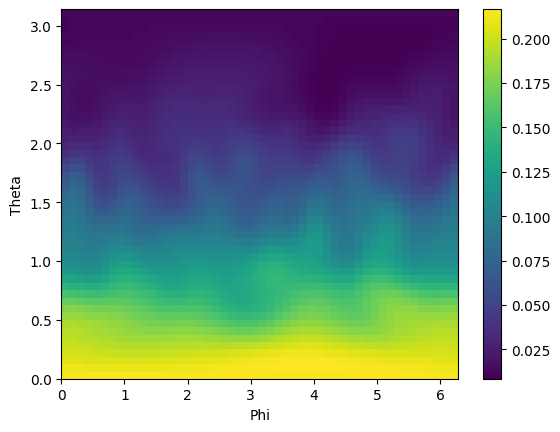

In [140]:
# Apply KDE with correct Riemannian volume normalization
times = [0.1, 0.5, 1.0, 2.0]
time_index = 2 # Use t = 1.0 as an example
theta_grid, phi_grid, normalized_density_sphere, dtheta, dphi = estimate_density(positions_at_times, time_index)

# Display on heatmap
plt.imshow(normalized_density_sphere,
           origin="lower",
           extent=[0, 2*np.pi, 0, np.pi],
           aspect="auto")
plt.xlabel("Phi")
plt.ylabel("Theta")
plt.colorbar()
plt.show()

Validate that the empirical density is approximately one with respect to the spherical area element for each of the four times. In other words, we want to demonstrate that

$$
\int_{S^2} \hat{p}_t(\theta,\phi),dV \approx 1
$$

for $t = 0.1, 0.5, 1.0, 2.0$.


In [141]:
# t = 0.1
density = np.sum(normalized_density_sphere * np.sin(theta_grid)[:, None] * dtheta * dphi)
assert np.isclose(density, 1.0, atol=0.001)
print("Density at t=0.1: ")
print(density)
# t = 0.5
density = np.sum(normalized_density_sphere * np.sin(theta_grid)[:, None] * dtheta * dphi)
assert np.isclose(density, 1.0, atol=0.001)
print("Density at t=0.5: ")
print(density)
# t = 1.0
density = np.sum(normalized_density_sphere * np.sin(theta_grid)[:, None] * dtheta * dphi)
assert np.isclose(density, 1.0, atol=0.001)
print("Density at t=1.0: ")
print(density)
# t = 2.0
density = np.sum(normalized_density_sphere * np.sin(theta_grid)[:, None] * dtheta * dphi)
assert np.isclose(density, 1.0, atol=0.001)
print("Density at t=2.0: ")
print(density)

Density at t=0.1: 
1.0000000000000002
Density at t=0.5: 
1.0000000000000002
Density at t=1.0: 
1.0000000000000002
Density at t=2.0: 
1.0000000000000002


The spectral expansion of the theoretical heat kernel is expressed as

$$
\frac{1}{4\pi}
\sum_{\ell=0}^{\infty}
(2\ell+1)
e^{-\ell(\ell+1)t}
P_\ell(\cos\theta),
$$

where $P_\ell$ represents the Legendre polynomial of degree $\ell$.

In this implementation, we will truncate the infinite series at $\ell = L = 50$ to approximate the series while limiting runtime. Additionally,

$$
p_t(\theta,\phi) = p_t(\theta),
$$

since the starting point of this simulation is the north pole of the sphere and the sphere is rotationally symmetric around that axis.


In [142]:
# Animate spreading distribution on S^2 across time steps
# Create initial frame with the grids and normalized density
init_heatmap = go.Heatmap(
    x=phi_grid,
    y=theta_grid,
    z=normalized_density_sphere,
    colorscale="Viridis"
)

# Create frames for remaining time indices
heatmap_frames = []
for i in range(1, 4):
    theta_grid, phi_grid, normalized_density_sphere, dtheta, dphi = estimate_density(positions_at_times, i)
    z_frame = normalized_density_sphere
    heatmap_frames.append(
        go.Frame(
            data=[go.Heatmap(
                x=phi_grid,
                y=theta_grid,
                z=z_frame)],
            name=f"Time step: {times[i]}"
        )
    )

# Plot figure with all frames and a play button for animation
figure = go.Figure(
    data=[init_heatmap],
    frames=heatmap_frames,
    layout=go.Layout(
        title="Spreading Distribution on Sphere",
        xaxis=dict(title="Phi"),
        yaxis=dict(title="Theta"),
        updatemenus=[{
            "type": "buttons",
            "buttons": [
                {
                    "label": "Play",
                    "method": "animate",
                    "args": [
                        None,
                        {
                            "frame": {"duration": 600, "redraw": True}, # Set redraw to true to prevent frozen animation
                            "fromcurrent": True,
                            "transition": {"duration": 200}
                        }
                    ]
                }
            ]
        }]
    )
)

figure.show()

In [143]:
# Calculate theoretical heat kernel densities
theoretical_densities = []
for t in times:
    theoretical_density = estimate_theoretical_heat_kernel(theta_grid, phi_grid, t)
    theoretical_densities.append(theoretical_density)

To validate the theoretical heat kernel, test that each density is normalized for all four times and that, as $t$ increases, the theoretical heat kernel approaches the uniform density

$$
\frac{1}{4\pi}
$$


In [144]:
# Test every density is normalized
for i in range(4):
    theta_grid, phi_grid, normalized_density, dtheta, dphi = estimate_density(positions_at_times, i)
    density = np.sum(normalized_density * np.sin(theta_grid)[:, None] * dtheta * dphi)
    assert np.isclose(density, 1.0, atol=0.001)
    print(f"Density at t={times[i]}: {density}")

print()

# Test theoretical kernel approaches 1 / 4pi
for i in range(4):
    theo_heat_kernel = estimate_theoretical_heat_kernel(theta_grid, phi_grid, times[i])
    difference = np.max(np.abs(theo_heat_kernel - (1 / (4 * np.pi))))
    print(f"Difference at t={times[i]}: {difference}")

Density at t=0.1: 1.0
Density at t=0.5: 1.0000000000000002
Density at t=1.0: 1.0000000000000002
Density at t=2.0: 1.0

Difference at t=0.1: 0.7432639516075943
Difference at t=0.5: 0.10904794604621677
Difference at t=1.0: 0.03329860716927405
Difference at t=2.0: 0.00437498142298999


As expected, the maximum difference between the theoretical heat kernel and the uniform density $\frac{1}{4\pi}$ decreases as time increases.

Now that there are two densities: the empirical density $\hat{p}_t(\theta,\phi)$ (obtained from the 2000 simulated paths) and the theoretical density $p_t(\theta)$ (obtained from the spectral expansion), we must verify that they are similar. This is done by visually comparing the empirical distribution with the theoretical heat kernel at each time.


First, we compare each time individually by displaying an empirical heatmap and the theoretical contour lines.

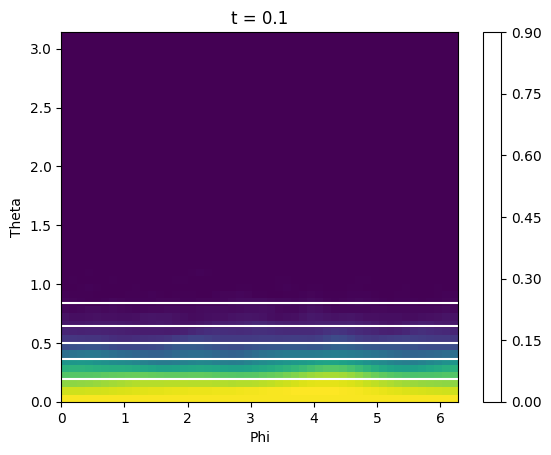

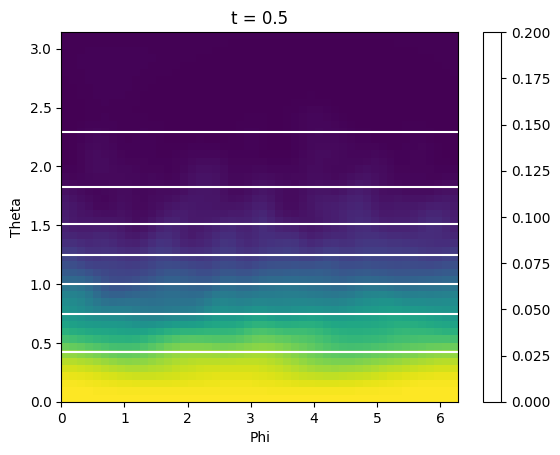

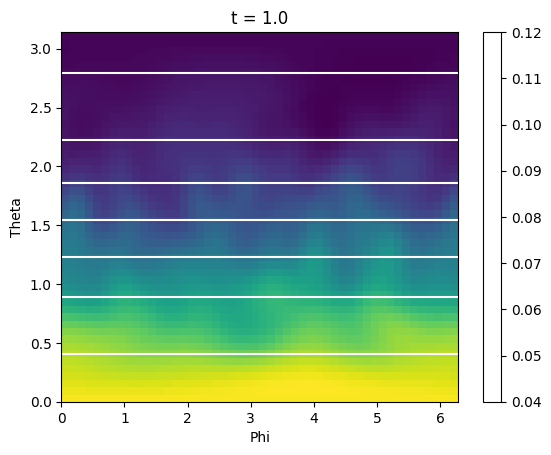

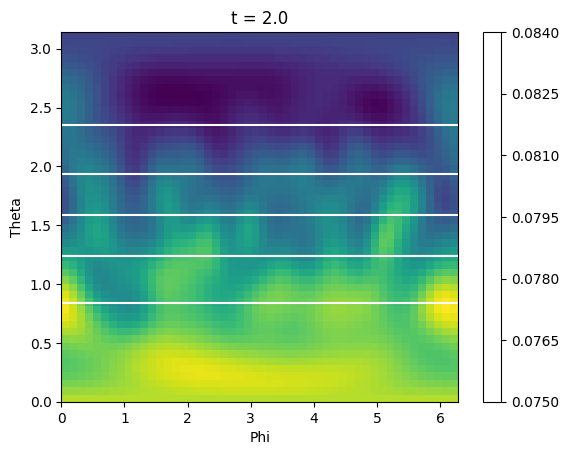

In [145]:
for i in range(4):
    theta_grid, phi_grid, normalized_density, dtheta, dphi = estimate_density(positions_at_times, i)
    theo_heat_kernel = estimate_theoretical_heat_kernel(theta_grid, phi_grid, times[i])
    
    # Display on heatmap
    plt.imshow(normalized_density,
            origin="lower",
            extent=[0, 2*np.pi, 0, np.pi],
            aspect="auto")

    # Add contour lines to same plot
    plt.contour(phi_grid,
                theta_grid,
                theo_heat_kernel,
                colors="white")
    plt.title(f"t = {times[i]}")
    plt.xlabel("Phi")
    plt.ylabel("Theta")
    plt.colorbar()
    plt.show()

In [146]:
# Create initial theoretical contour
init_theoretical_contour = go.Contour(
    x=phi_grid,
    y=theta_grid,
    z=theoretical_densities[0],
    contours=dict(coloring="none"),
    line=dict(color="white"),
    showscale=False
)

Finally, create an animation with frames that contain the empirical heatmap and the theoretical contour lines. The animation will show the distribution at $t=0.1$, $t=0.5$, $t=1.0$, and $t=2.0$.


In [147]:
overlayed_frames = []
for i in range(1, 4):
    theta_grid, phi_grid, normalized_density_sphere, dtheta, dphi = estimate_density(positions_at_times, i)
    z_frame = normalized_density_sphere
    
    theoretical_contour = go.Contour(
        x=phi_grid,
        y=theta_grid,
        z=theoretical_densities[i],
        contours=dict(coloring="none"),
        line=dict(color="white"),
        showscale=False
    )
    
    overlayed_frames.append(
        go.Frame(
            data=[go.Heatmap(
                x=phi_grid,
                y=theta_grid,
                z=z_frame
                ),
                theoretical_contour
            ],
            name=f"Time step: {times[i]}"
        )
    )


# Plot figure with all frames and a play button for animation
figure = go.Figure(
    data=[init_heatmap, init_theoretical_contour],
    frames=overlayed_frames,
    layout=go.Layout(
        title="Spreading Distribution on Sphere (with Contour Lines)",
        xaxis=dict(title="Phi"),
        yaxis=dict(title="Theta"),
        updatemenus=[{
            "type": "buttons",
            "buttons": [
                {
                    "label": "Play",
                    "method": "animate",
                    "args": [
                        None,
                        {
                            "frame": {"duration": 600, "redraw": True}, # Set redraw to true to prevent frozen animation
                            "fromcurrent": True,
                            "transition": {"duration": 200}
                        }
                    ]
                }
            ]
        }]
    )
)

figure.show()

# Results

At $t=0.1$, the distribution is strongly concentrated near $\theta=0$, which is the north pole. At $t=0.5$, the distribution has spread out. At $t=1.0$, the particles are distributed over a larger portion of the sphere. At $t=2.0$, the distribution is closer to uniform.

The theoretical contours follow the general shape of the empirical heatmap, showing that the empirical distribution is approximately consistent with the theoretical distribution, as expected.